# 5.2 Google Trends — State-Level Analysis

State-level Google Trends analysis for the 2024 US presidential election: search gap rankings, swing state focus, home state effects, and correlation heatmaps across keywords.

**Input:** `Data/1_Bronze/Google_Trends/trends_by_state.csv`


<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Search Gap Ranking](#1-search-gap-ranking)
- [2. Swing State Focus](#2-swing-state-focus)
- [3. Home State Effects](#3-home-state-effects)
- [4. `election 2024` Search Interest by State](#4-election-2024-search-interest-by-state)
- [5. Correlation Heatmap](#5-correlation-heatmap)
- [6. Trump Search Interest Heatmap](#6-trump-search-interest-heatmap)
- [7. Animated Choropleth](#7-animated-choropleth)


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')
from house_style import *
apply_style()

BRONZE_PATH = '../../Data/1_Bronze/Google_Trends/'

KEYWORDS = ['trump', 'kamala', 'vance', 'walz', 'election 2024']

COLOR_MAP = {
    'trump'        : REPUBLICAN,
    'kamala'       : DEMOCRAT,
    'vance'        : '#ef5350',
    'walz'         : '#4fc3f7',
    'election 2024': NEUTRAL,
}

SWING_STATES = ['Arizona', 'Georgia', 'Michigan', 'Nevada',
                'North Carolina', 'Pennsylvania', 'Wisconsin']

print('Ready.')

Ready.


In [2]:
df = pd.read_csv(f'{BRONZE_PATH}trends_by_state.csv', index_col='geoName')

print(f'Shape: {df.shape}  ({df.shape[0]} states × {df.shape[1]} keywords)')
print(f'\nKeywords: {df.columns.tolist()}')
print(f'\nData quality — zero values per keyword:')
print((df == 0).sum().rename('zero_count'))
print(f'\nSummary statistics:')
df.describe().round(2)

Shape: (51, 5)  (51 states × 5 keywords)

Keywords: ['trump', 'kamala', 'vance', 'walz', 'election 2024']

Data quality — zero values per keyword:
trump            0
kamala           0
vance            0
walz             0
election 2024    0
Name: zero_count, dtype: int64

Summary statistics:


,trump,kamala,vance,walz,election 2024
count,51.00,51.00,51.00,51.00,51.00
mean,59.49,21.75,8.98,5.76,4.02
std,2.78,1.95,0.91,1.88,0.73
min,46.00,18.00,7.00,4.00,3.00
25%,59.00,21.00,8.00,5.00,4.00
50%,60.00,22.00,9.00,5.00,4.00
75%,61.00,23.00,9.50,6.00,4.00
max,64.00,29.00,11.00,16.00,6.00


## 1. Search Gap Ranking

Positive = Trump searched more. Negative = Kamala searched more. Colour = 2024 election result.

Trump leads in 51/51 states
Kamala leads in 0/51 states

Top 5 Trump-leading states:
geoName
North Dakota     45
Montana          45
West Virginia    44
Wyoming          43
Rhode Island     43
dtype: int64

Top 5 Kamala-leading states:
geoName
District of Columbia    17
Georgia                 31
Massachusetts           32
Maryland                32
California              34
dtype: int64


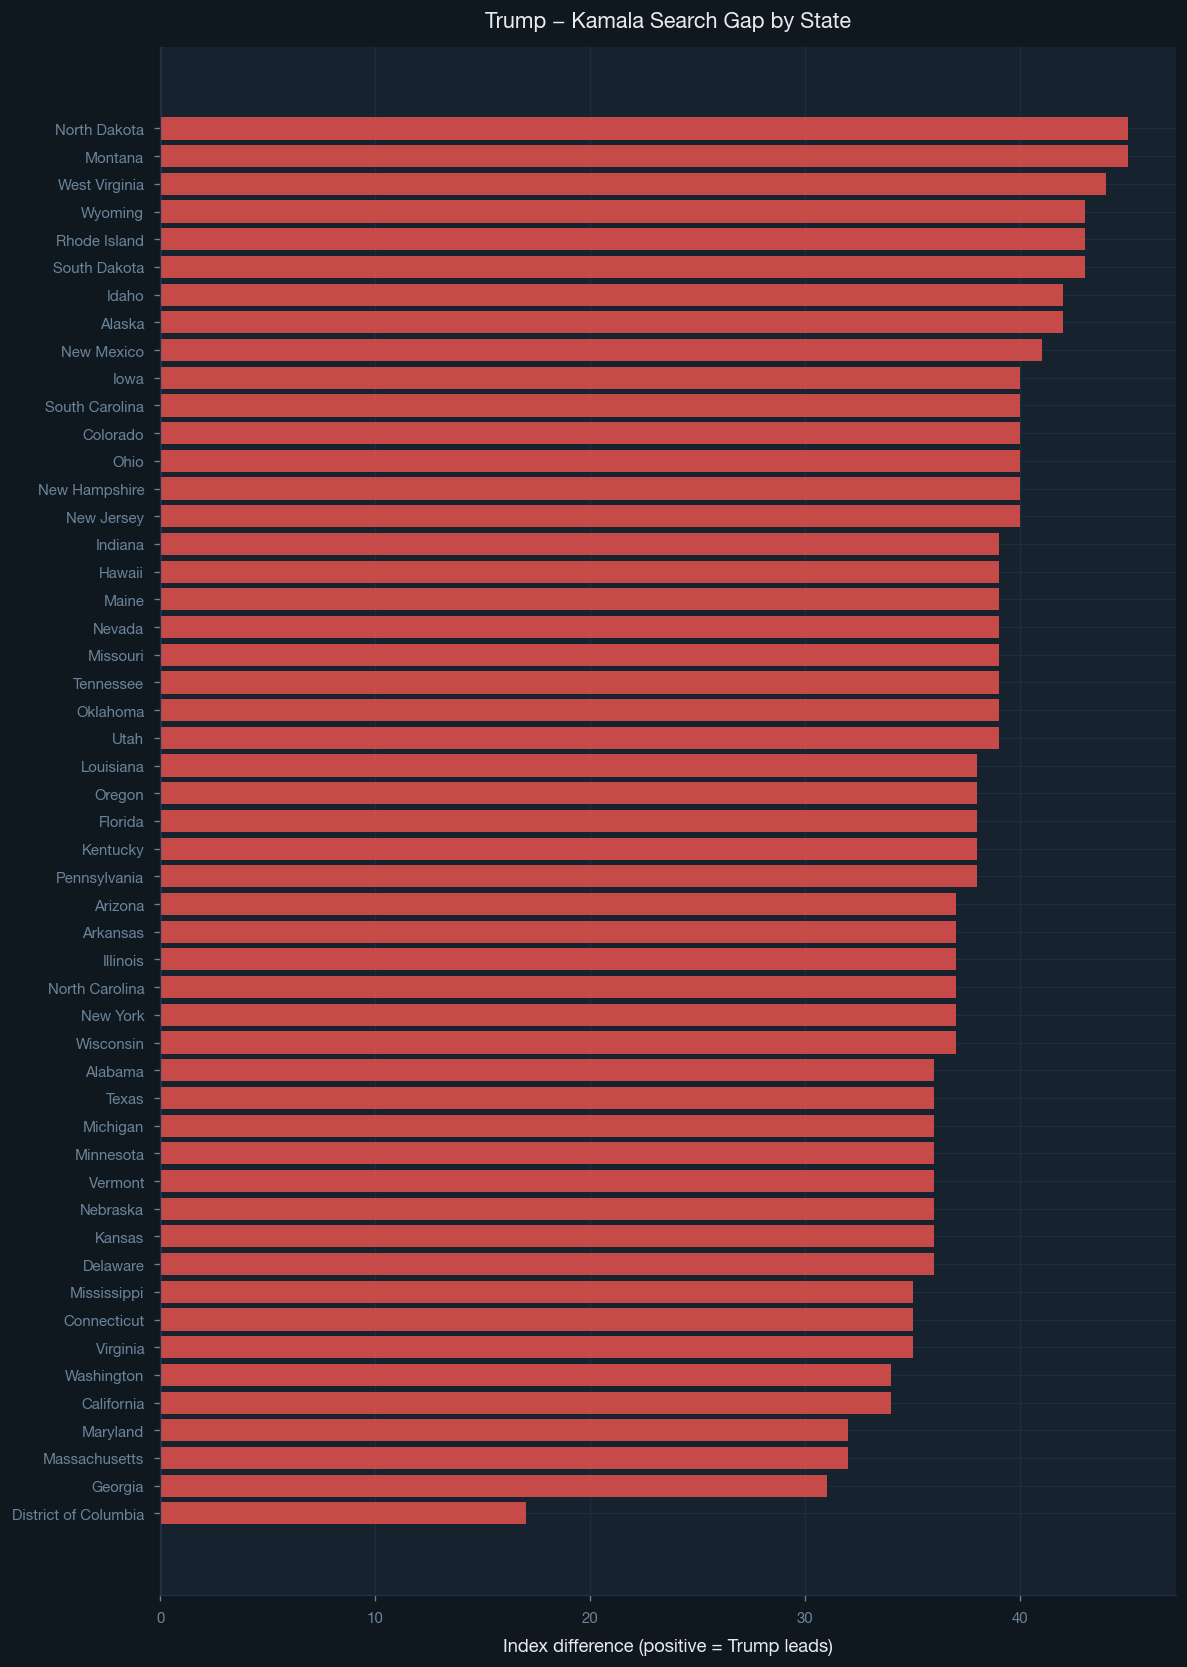

In [3]:
gap = (df['trump'] - df['kamala']).sort_values()

fig, ax = styled_fig(figsize=(10, 14))

colors = [DEMOCRAT if v < 0 else REPUBLICAN for v in gap]
ax.barh(gap.index, gap.values, color=colors, alpha=0.85)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.8)

style_ax(ax, title='Trump − Kamala Search Gap by State',
         xlabel='Index difference (positive = Trump leads)', grid_axis='x')

trump_leading = (gap > 0).sum()
print(f'Trump leads in {trump_leading}/51 states')
print(f'Kamala leads in {51 - trump_leading}/51 states')
print(f'\nTop 5 Trump-leading states:')
print(gap.tail(5).iloc[::-1].round(1))
print(f'\nTop 5 Kamala-leading states:')
print(gap.head(5).round(1))

plt.tight_layout()
plt.show()

## 2. Swing State Focus

The 2024 election was decided in 7 key swing states. How did search interest differ there?

Swing state search interest:
                trump  kamala  vance  walz  election 2024  trump_lead
geoName                                                              
Nevada             62      23      7     4              4          39
Pennsylvania       61      23      8     5              3          38
Arizona            60      23      8     5              4          37
North Carolina     59      22      9     6              4          37
Wisconsin          59      22      9     7              3          37
Michigan           59      23      8     6              4          36
Georgia            57      26      8     5              4          31


/var/folders/4r/kx0lc74n42j94_8kv0y_lcm80000gn/T/ipykernel_49922/1660091993.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(swing_df.index, rotation=30, ha='right', fontsize=8)


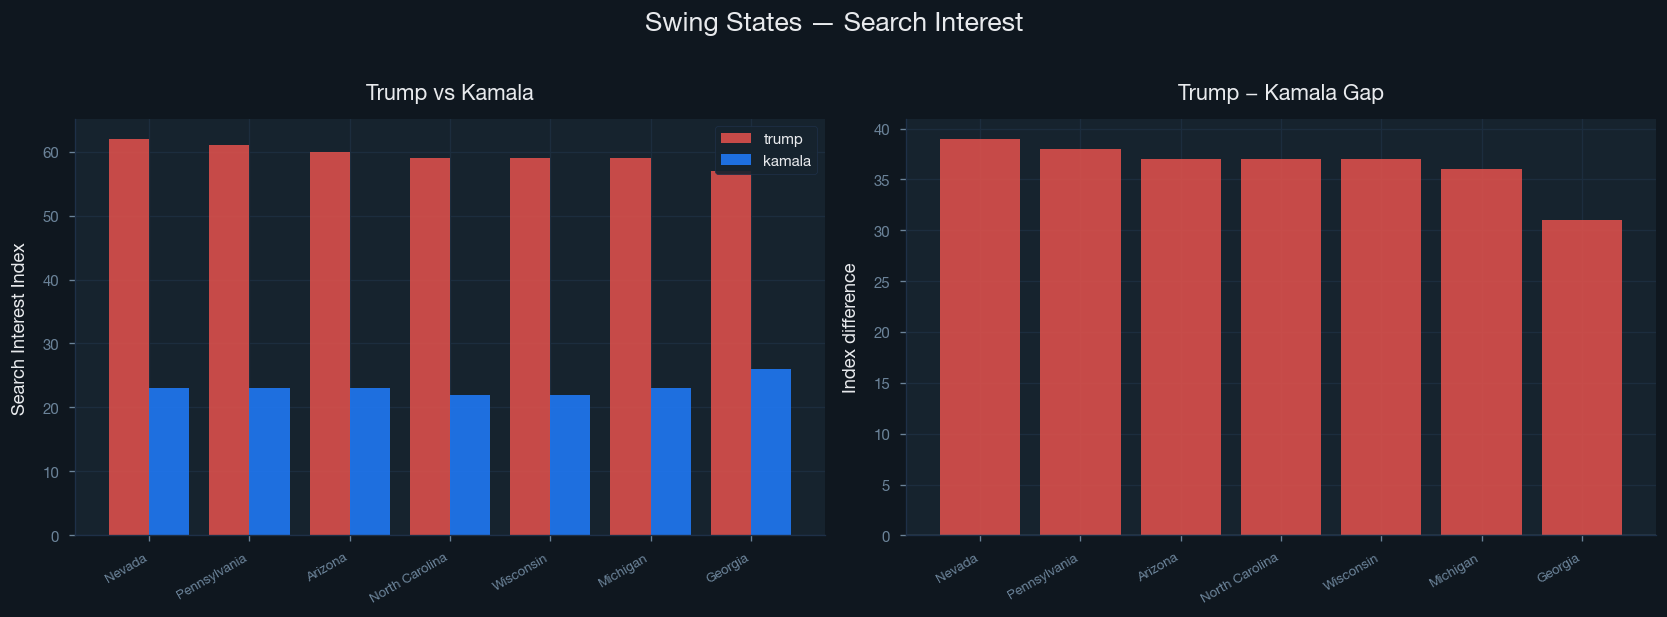

In [4]:
swing_df = df.loc[SWING_STATES, ['trump', 'kamala', 'vance', 'walz', 'election 2024']].copy()
swing_df['trump_lead'] = swing_df['trump'] - swing_df['kamala']
swing_df = swing_df.sort_values('trump_lead', ascending=False)

print('Swing state search interest:')
print(swing_df.round(2).to_string())

fig, axes = styled_fig(nrows=1, ncols=2, figsize=(14, 5),
                       title='Swing States — Search Interest')

ax = axes[0]
x = np.arange(len(swing_df))
ax.bar(x - 0.2, swing_df['trump'],  width=0.4, color=REPUBLICAN, alpha=0.85, label='trump')
ax.bar(x + 0.2, swing_df['kamala'], width=0.4, color=DEMOCRAT,   alpha=0.85, label='kamala')
ax.set_xticks(x)
ax.set_xticklabels(swing_df.index, rotation=30, ha='right', fontsize=8)
style_ax(ax, title='Trump vs Kamala', ylabel='Search Interest Index')
ax.legend()

ax = axes[1]
colors = [REPUBLICAN if v >= 0 else DEMOCRAT for v in swing_df['trump_lead']]
ax.bar(swing_df.index, swing_df['trump_lead'], color=colors, alpha=0.85)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8)
ax.set_xticklabels(swing_df.index, rotation=30, ha='right', fontsize=8)
style_ax(ax, title='Trump − Kamala Gap', ylabel='Index difference')

plt.tight_layout()
plt.show()

## 3. Home State Effects

VP candidates often get disproportionate search interest in their home states.

walz: national avg = 5.8, Minnesota = 16.0  (2.8x national avg)
vance: national avg = 9.0, Ohio = 11.0  (1.2x national avg)


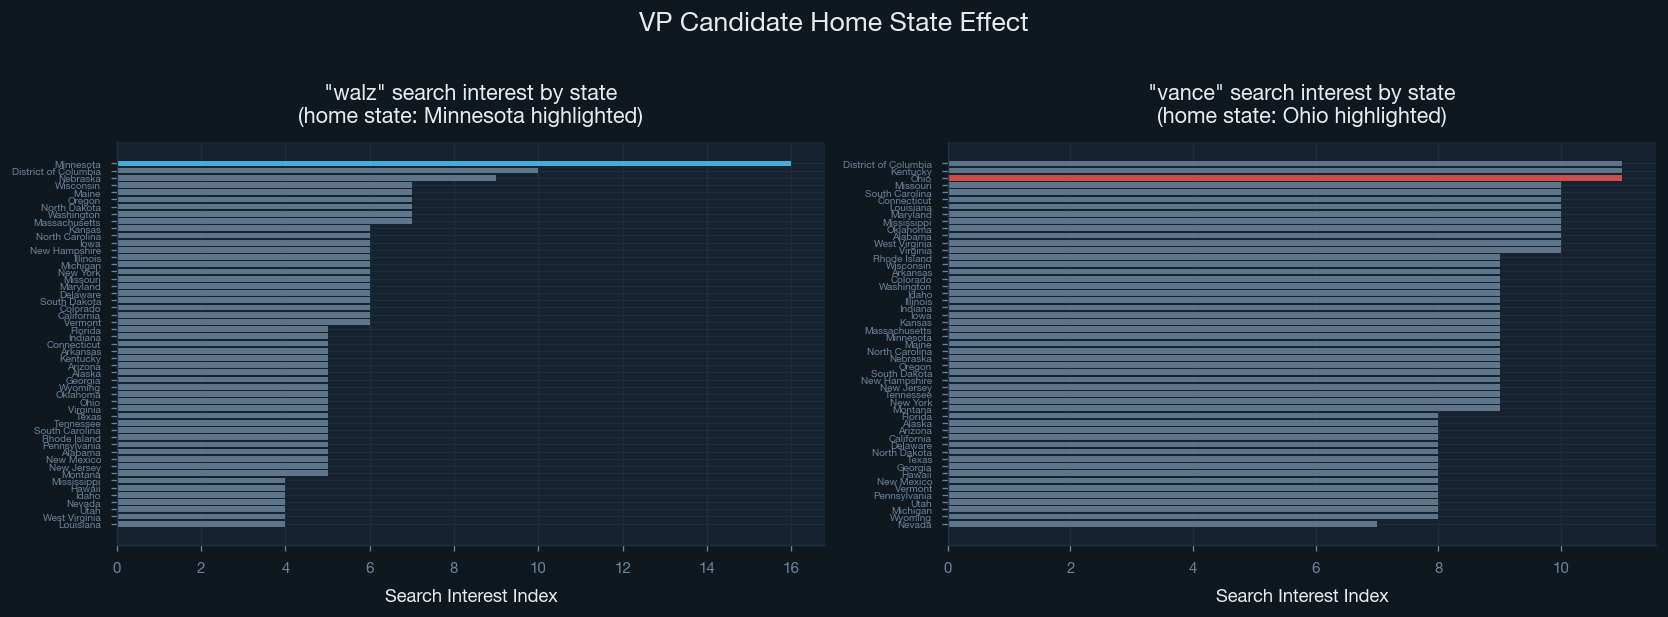

In [5]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(14, 5),
                       title='VP Candidate Home State Effect')

for ax, (kw, home_state, color) in zip(axes, [
    ('walz',  'Minnesota', COLOR_MAP['walz']),
    ('vance', 'Ohio',      COLOR_MAP['vance']),
]):
    series = df[kw].sort_values(ascending=True)
    bar_colors = [color if s == home_state else TEXT_MUTED for s in series.index]
    ax.barh(series.index, series.values, color=bar_colors, alpha=0.85)
    style_ax(ax, title=f'"{kw}" search interest by state\n(home state: {home_state} highlighted)',
             xlabel='Search Interest Index', grid_axis='x')
    ax.tick_params(axis='y', labelsize=6)

    nat_avg = df[kw].mean()
    home_val = df.loc[home_state, kw]
    print(f'{kw}: national avg = {nat_avg:.1f}, {home_state} = {home_val:.1f}  ({home_val/nat_avg:.1f}x national avg)')

plt.tight_layout()
plt.show()

## 4. `election 2024` Search Interest by State

High search volumes may indicate competitive races or strong voter engagement.

Highest "election 2024" search: {'Wyoming': 6, 'Kansas': 5, 'Alaska': 5}
Lowest  "election 2024" search: {'Alabama': 3, 'Maine': 3, 'Mississippi': 3}


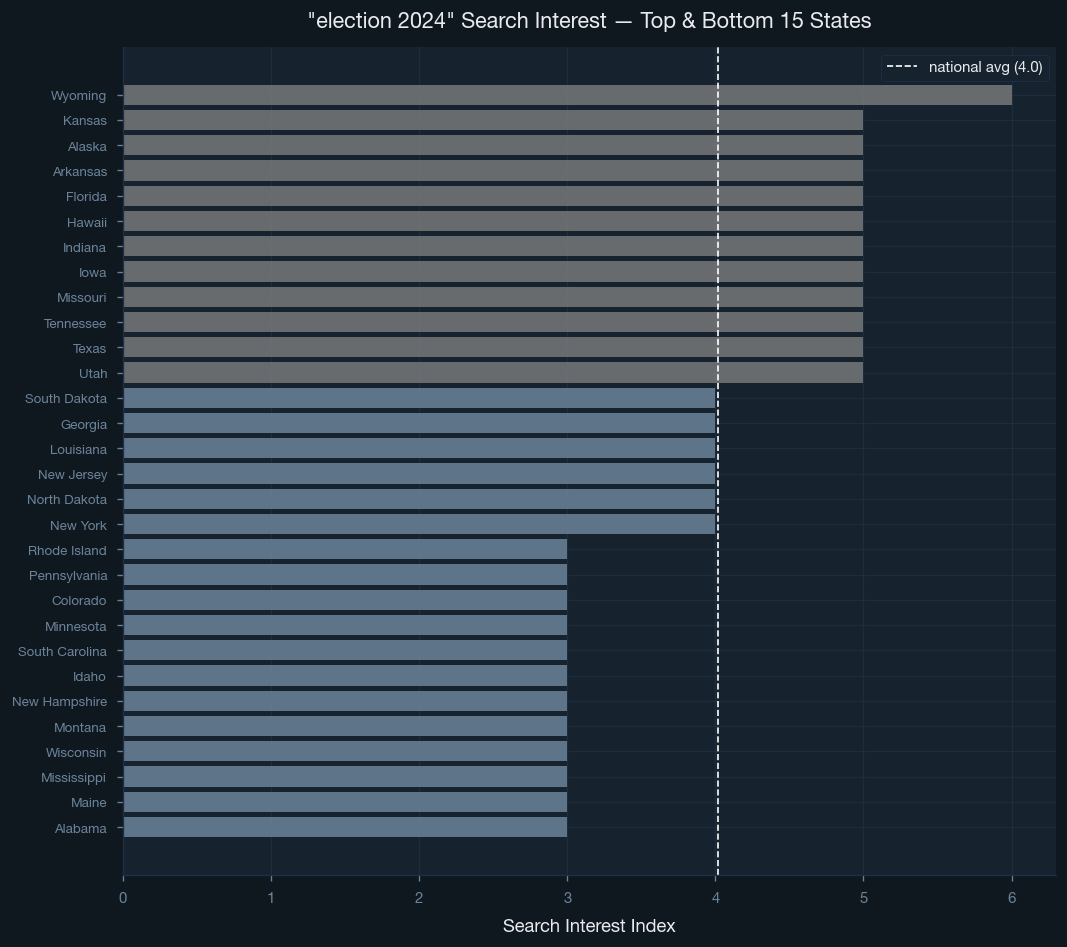

In [6]:
elec_sorted = df['election 2024'].sort_values()
nat_avg_elec = elec_sorted.mean()

top15    = elec_sorted.tail(15)
bottom15 = elec_sorted.head(15)
display_series = pd.concat([bottom15, top15])

fig, ax = styled_fig(figsize=(9, 8))
bar_colors = [COLOR_MAP['election 2024'] if v >= nat_avg_elec else TEXT_MUTED for v in display_series]
ax.barh(display_series.index, display_series.values, color=bar_colors, alpha=0.85)
ax.axvline(nat_avg_elec, color='white', linewidth=1, linestyle='--',
           label=f'national avg ({nat_avg_elec:.1f})')
style_ax(ax, title='"election 2024" Search Interest — Top & Bottom 15 States',
         xlabel='Search Interest Index', grid_axis='x')
ax.legend()
ax.tick_params(axis='y', labelsize=8)

print(f'Highest "election 2024" search: {top15.tail(3).iloc[::-1].round(1).to_dict()}')
print(f'Lowest  "election 2024" search: {bottom15.head(3).round(1).to_dict()}')

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

Do states that search a lot for Trump also search for Vance? Which keywords cluster together across states?

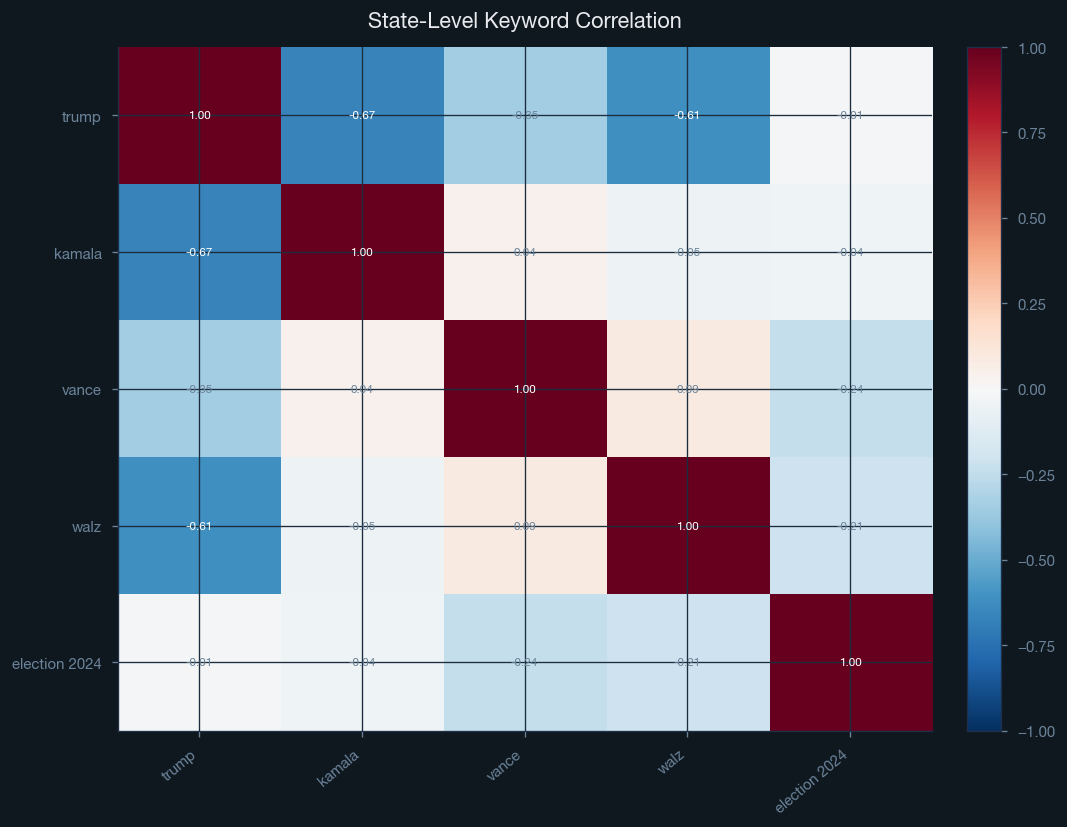


Strongest correlations (excluding self):
trump   kamala          -0.67
        walz            -0.61
        vance           -0.35
vance   election 2024   -0.24
walz    election 2024   -0.21
vance   walz             0.09
kamala  walz            -0.05
        vance            0.04
        election 2024   -0.04
trump   election 2024   -0.01
dtype: float64


In [7]:
# Drop zero-variance columns before computing correlations
valid_cols = [c for c in df.columns if df[c].std() > 0]
corr = df[valid_cols].corr().round(2)

fig, ax = styled_fig(figsize=(9, 7))

# Diverging colormap centred at 0
cmap = plt.cm.RdBu_r
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(valid_cols)))
ax.set_yticks(range(len(valid_cols)))
ax.set_xticklabels(valid_cols, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(valid_cols, fontsize=9)

for i in range(len(valid_cols)):
    for j in range(len(valid_cols)):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(val) > 0.5 else TEXT_MUTED)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
style_ax(ax, title='State-Level Keyword Correlation')

plt.tight_layout()
plt.show()

print('\nStrongest correlations (excluding self):')
corr_unstacked = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False)
print(corr_unstacked.head(10).round(2))

## 6. Trump Search Interest Heatmap

Each row is a US state, each column a week. Colour intensity = search interest.

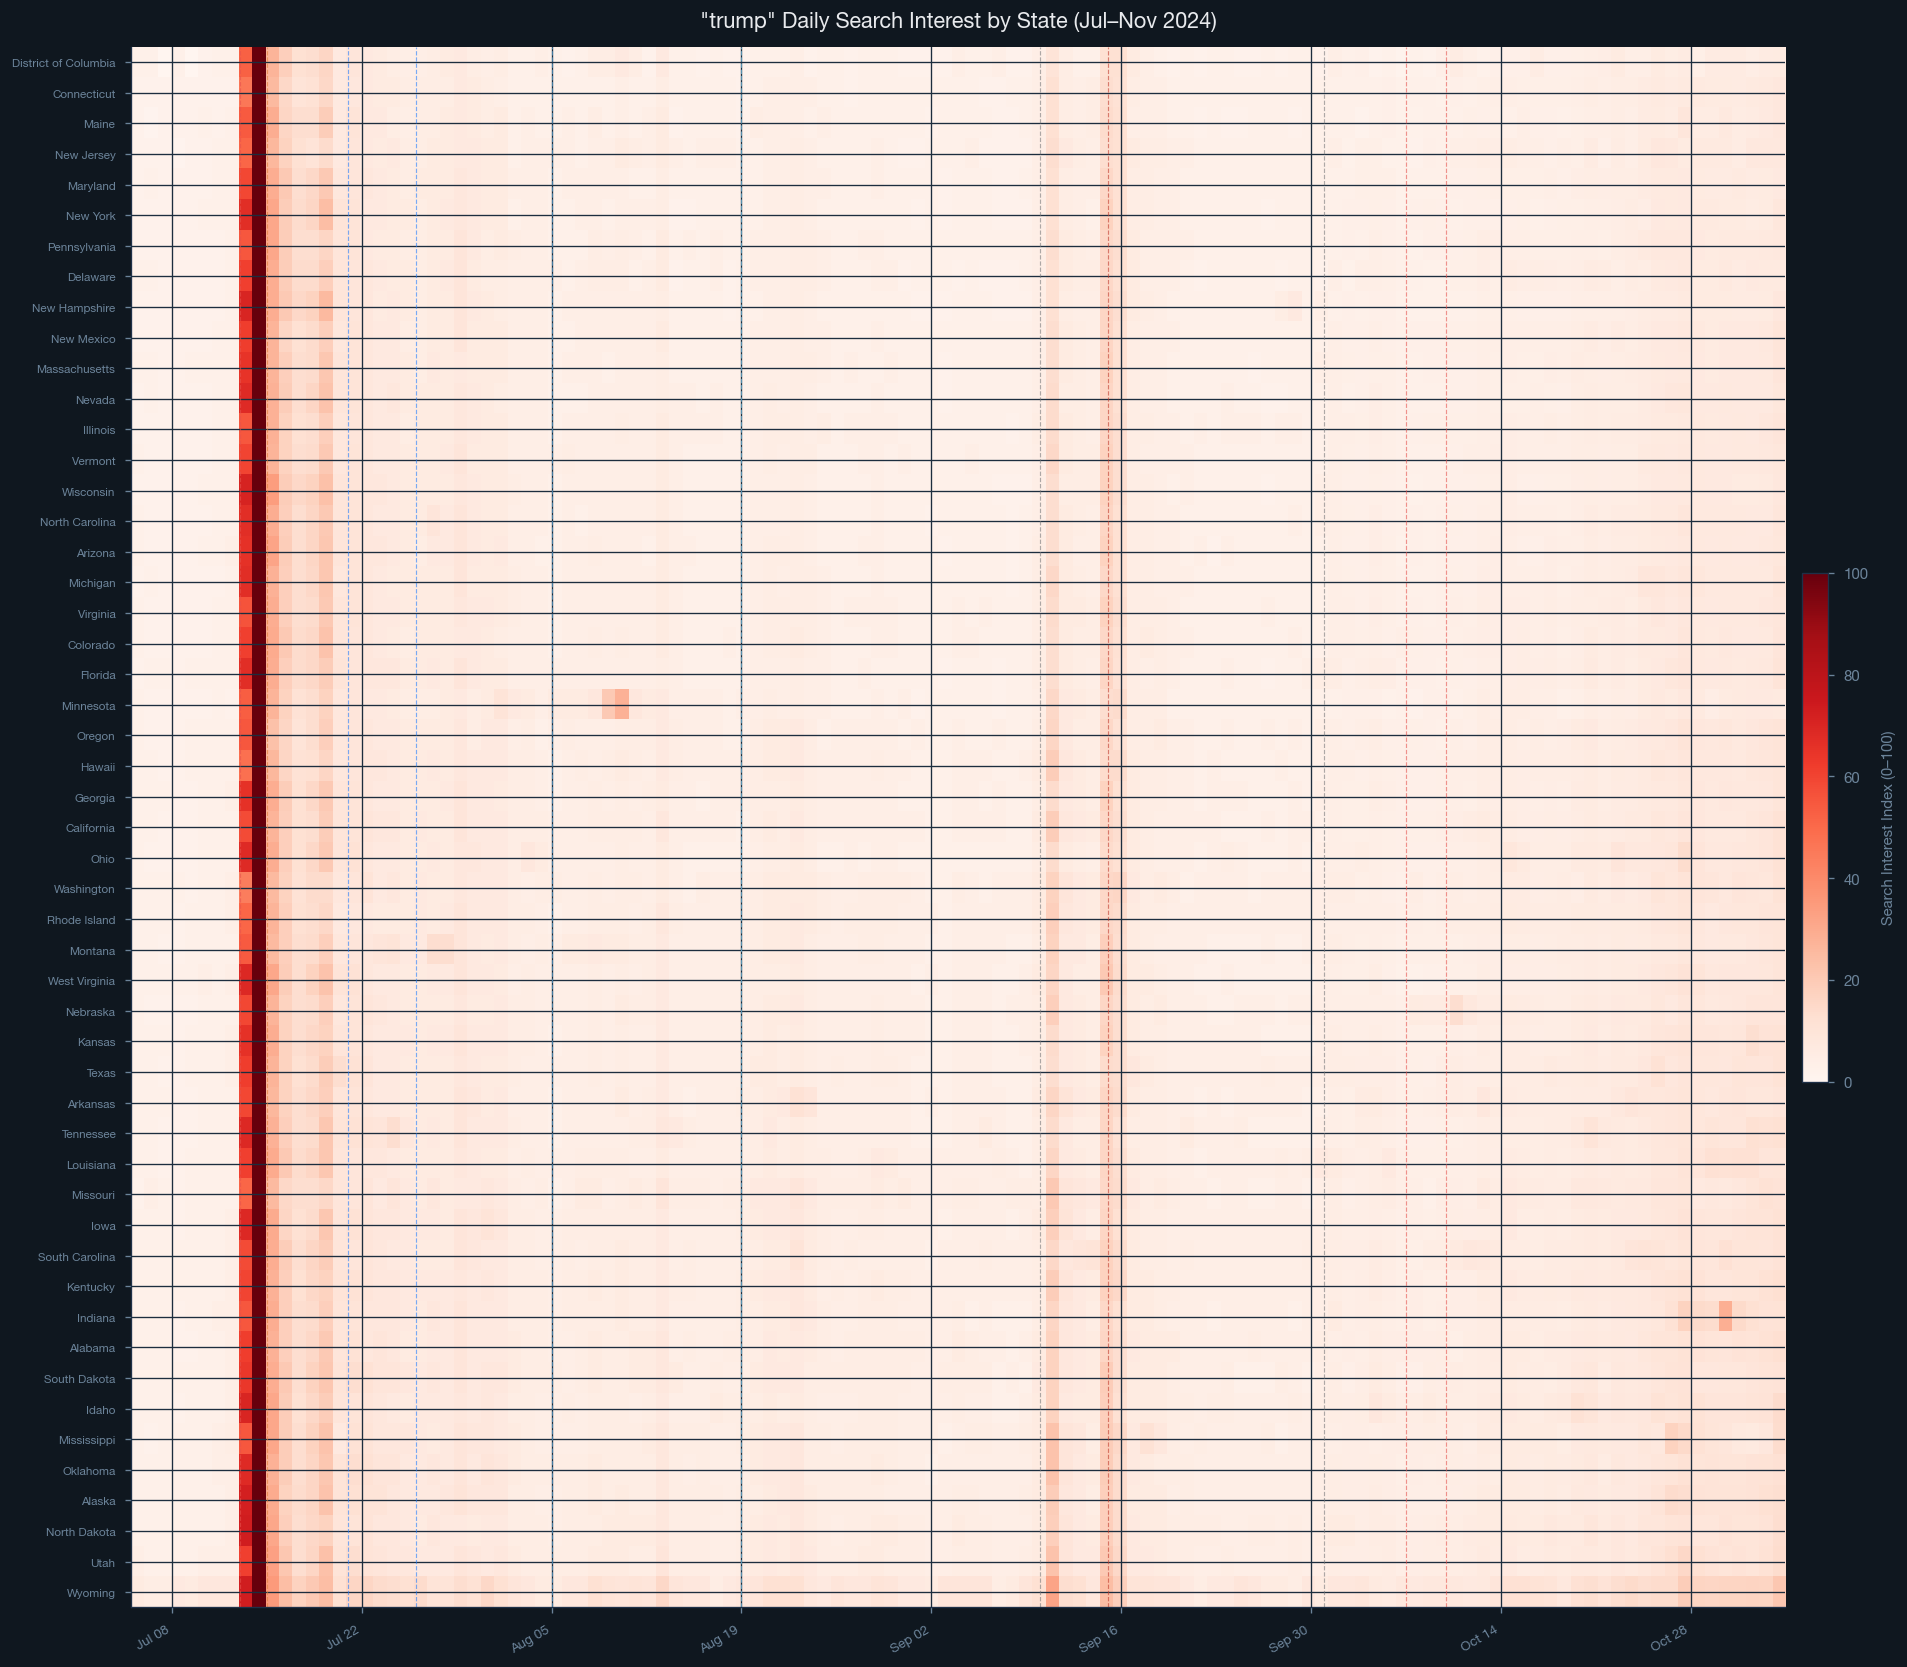

In [8]:
import matplotlib.dates as mdates

df_ts = pd.read_csv(f'{BRONZE_PATH}trump_daily_by_state.csv',
                    index_col='date', parse_dates=True)

# Sort states by average search interest (highest at top)
state_order = df_ts.mean().sort_values(ascending=True).index
matrix = df_ts[state_order].T   # shape: (51 states × 123 days)

fig, ax = plt.subplots(figsize=(16, 14))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)

im = ax.imshow(
    matrix.values,
    aspect='auto',
    cmap='Reds',
    interpolation='nearest',
    vmin=0, vmax=100,
    extent=[mdates.date2num(df_ts.index.min()),
            mdates.date2num(df_ts.index.max()),
            -0.5, len(state_order) - 0.5]
)

# Event lines from house_style.EVENTS
for lbl, date_str, color in EVENTS:
    d = pd.Timestamp(date_str)
    if df_ts.index.min() <= d <= df_ts.index.max():
        ax.axvline(mdates.date2num(d), color=color, linewidth=0.7,
                   linestyle='--', alpha=0.6)

# Axes formatting
ax.set_yticks(range(len(state_order)))
ax.set_yticklabels(state_order, fontsize=7)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', color=TEXT_MUTED, fontsize=8)
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.set_title('"trump" Daily Search Interest by State (Jul–Nov 2024)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold', pad=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cbar.set_label('Search Interest Index (0–100)', color=TEXT_MUTED, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_MUTED)

plt.tight_layout()
plt.show()

## 7. Animated Choropleth

Trump search interest over time, animated across US states.

In [9]:
import plotly.graph_objects as go
import pandas as pd

BRONZE_PATH_DATA = '../../data/1_bronze/google_trends/'

STATE_ABBREV = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'District of Columbia': 'DC', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI',
    'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY',
}
SWING_STATES_SET = {'Arizona', 'Georgia', 'Michigan', 'Nevada',
                    'North Carolina', 'Pennsylvania', 'Wisconsin'}

states  = list(STATE_ABBREV.keys())
abbrevs = [STATE_ABBREV[s] for s in states]

df_state = pd.read_csv(f'{BRONZE_PATH_DATA}trends_by_state.csv', index_col='geoName')

KEYWORD_STYLE = {
    'trump'         : ('Reds',    'Trump'),
    'kamala'        : ('Blues',   'Kamala Harris'),
    'biden'         : ('Blues',   'Biden'),
    'elon musk'     : ('Oranges', 'Elon Musk'),
    'election 2024' : ('Purples', 'Election 2024'),
    'vote'          : ('Greens',  'Vote'),
    'walz'          : ('Blues',   'Walz'),
    'vance'         : ('Reds',    'Vance'),
}

for kw, (colorscale, label) in KEYWORD_STYLE.items():
    if kw not in df_state.columns:
        continue
    values = [float(df_state.loc[s, kw]) if s in df_state.index else 0 for s in states]
    vmax   = max(values) if max(values) > 0 else 100

    fig = go.Figure(go.Choropleth(
        locations=abbrevs,
        z=values,
        locationmode='USA-states',
        colorscale=colorscale,
        zmin=0, zmax=vmax,
        marker_line_color='rgba(255,255,255,0.3)',
        marker_line_width=0.5,
        colorbar_title='Search<br>Index',
        text=[f"<b>{s}</b>{' swing' if s in SWING_STATES_SET else ''}<br>{v:.0f}"
              for s, v in zip(states, values)],
        hoverinfo='text',
    ))
    fig.update_layout(
        title={'text': f'"{label}" — Avg Google Search Interest by State (Jul–Nov 2024)',
               'font': {'size': 15, 'color': '#f5f5f5'}, 'x': 0.5},
        geo=dict(scope='usa', projection_type='albers usa',
                 showlakes=True, lakecolor='#1a1a2e',
                 bgcolor='#1a1a2e', landcolor='#2e2e3e'),
        paper_bgcolor='#1a1a2e', font_color='#cccccc', height=400,
        margin={'t': 50, 'b': 10, 'l': 0, 'r': 0},
    )
    fig.show()
